In [1]:

import spatialdata as sd
import spatialdata_io
import spatialdata_plot
from napari_spatialdata import Interactive
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sdata = spatialdata_io.visium_hd('../data/Visium_HD_Liver/')

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_io/readers/visium_hd.py:99: UserWarning: File ../data/Visium_HD_Liver/../data/Visium_HD_Liver/microscope_image/SCA002_HE_hires_transposed.tif does not exist, skipping it.
  _load_image(


In [4]:
sdata

SpatialData object
├── Images
│     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
│     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
├── Shapes
│     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 1) (2D shapes)
│     └── 'Visium_HD_Liver_square_016um': GeoDataFrame shape: (115975, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (7375079, 19059)
      ├── 'square_008um': AnnData (462269, 19059)
      └── 'square_016um': AnnData (115975, 19059)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        Visium_HD_Liver_hires_image (Images), Visium_HD_Liver_square_002um (Shapes), Visium_HD_Liver_square_008um (Shapes), Visium_HD_Liver_square_016um (Shapes)
    ▸ 'downscaled_lowres', with elements:
        Visium_HD_Liver_lowres_image (Images), Visium_HD_Liver_square_002um (Shapes), Visium_HD_Liver_square_008um (Shapes), 

In [5]:
# Save shape objects
for bin_size in [8, 16]:
    sdata.tables[f'square_{bin_size:03}um'].obs.to_csv(f'../visium_hd_liver_combined/rds/shapes/square_{bin_size:03}um_locationid.csv')
    sdata.shapes[f'Visium_HD_Liver_square_{bin_size:03}um'].to_file(f'../visium_hd_liver_combined/rds/shapes/square_{bin_size:03}um.shp')

/tmp/ipykernel_186384/1425260301.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sdata.shapes[f'Visium_HD_Liver_square_{bin_size:03}um'].to_file(f'../visium_hd_liver_combined/rds/shapes/square_{bin_size:03}um.shp')
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'location_id' to 'location_i'
  ogr_write(
/tmp/ipykernel_186384/1425260301.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sdata.shapes[f'Visium_HD_Liver_square_{bin_size:03}um'].to_file(f'../visium_hd_liver_combined/rds/shapes/square_{bin_size:03}um.shp')
/home/cha

INFO     Rasterizing image for faster rendering.                                                                   


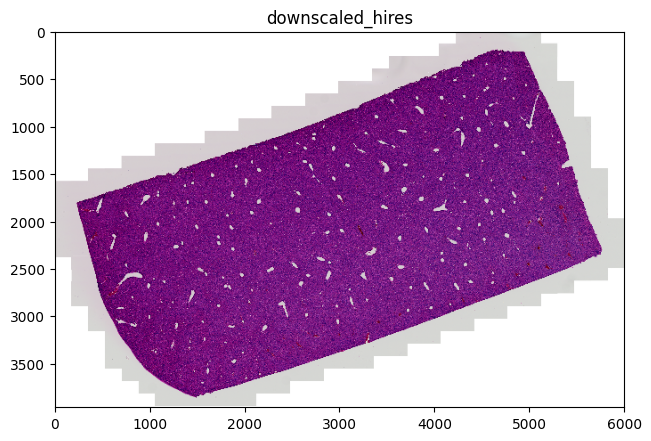

In [5]:
sdata.pl.render_images("Visium_HD_Liver_hires_image").pl.show(coordinate_systems="downscaled_hires")

In [8]:
bin_sizes = [2, 8, 16]

for bin_size in bin_sizes:
    bin_name = "square_{:03d}um".format(bin_size)
    # Get average counts per bin
    print("Average counts per {}um bin:".format(bin_size), end=" ")
    print(sdata.tables[bin_name].X.sum(axis=1).mean())

    # Get average number of genes per bin
    print("Average number of genes per {}um bin:".format(bin_size), end=" ")
    print(sdata.tables[bin_name].X.astype(bool).sum(axis=1).mean())

Average counts per 2um bin: 54.326286
Average number of genes per 2um bin: 41.95962375453877
Average counts per 8um bin: 867.9167
Average number of genes per 8um bin: 463.5214647748389
Average counts per 16um bin: 3464.06
Average number of genes per 16um bin: 1346.2733175253288


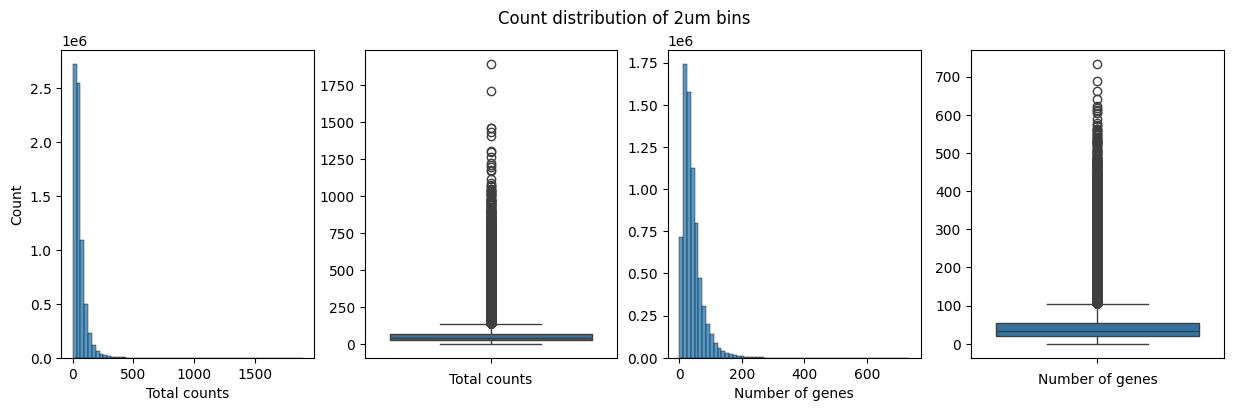

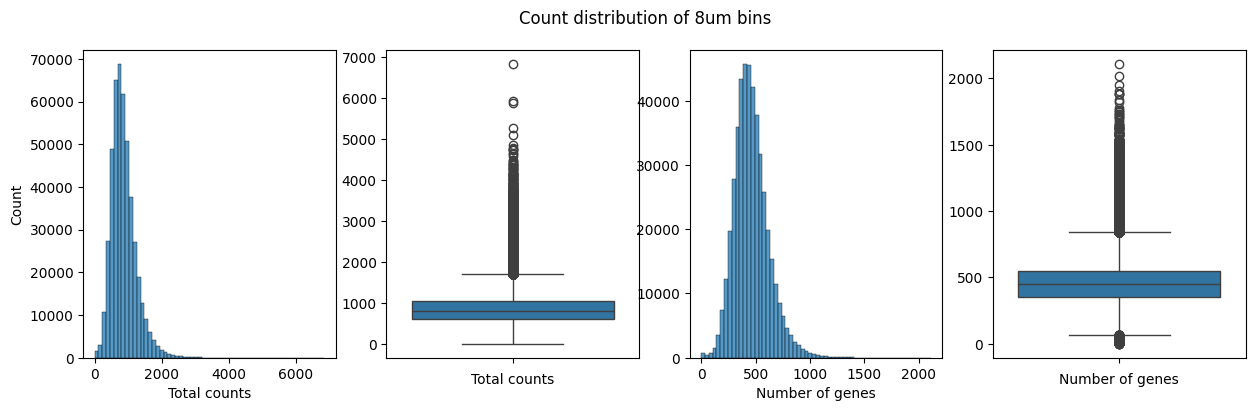

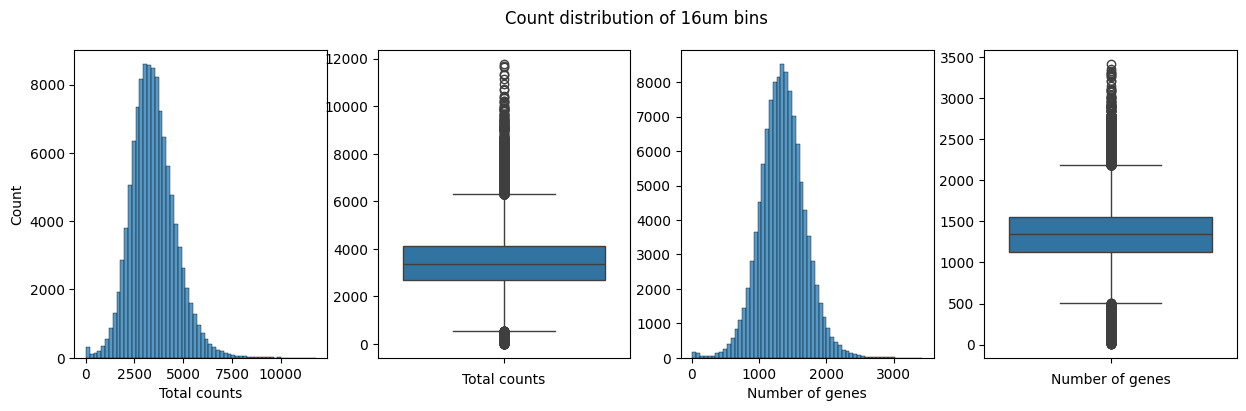

In [ ]:
for bin_size in bin_sizes:
    bin_name = "square_{:03d}um".format(bin_size)
    
    # Count distribution per bin size
    adata = sdata.tables[bin_name]
    adata.obs["total_counts"] = adata.X.sum(axis=1)
    adata.obs["n_genes_by_counts"] = (adata.X > 0).sum(axis=1)

    fig, axs = plt.subplots(1, 4, figsize=(15, 4))
    sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
    
    sns.boxplot(adata.obs["total_counts"], ax=axs[1])
    # sns.histplot(
    #     adata.obs["total_counts"][adata.obs["total_counts"] < 1000],
    #     kde=False,
    #     bins=40,
    #     ax=axs[1],
    # )
    sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
    sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])
    # sns.histplot(
    #     adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 500],
    #     kde=False,
    #     bins=60,
    #     ax=axs[3],
    # )

    # Set overall title
    fig.suptitle("Count distribution of {}um bins".format(bin_size))

    # Set title and labels
    axs[0].set_xlabel("Total counts")
    axs[1].set_xlabel("Total counts")
    axs[2].set_xlabel("Number of genes")
    axs[3].set_xlabel("Number of genes")

    # Turn off y-axis title
    axs[1].set_ylabel("")
    axs[2].set_ylabel("")
    axs[3].set_ylabel("")
    
    # Save plot
    plt.savefig("plots/histogram_count_genes_{}um.png".format(bin_size), dpi=300)


In [ ]:
# Check if Malat1, Neat1, and Xist are present in the data
for gene in ['Malat1', 'Neat1', 'Xist']:
    print(gene + " in data: " + str(gene in sdata.tables['square_008um'].var_names))


Malat1 in data: False
Neat1 in data: False
Xist in data: False


### Are Hnrnp genes expressed in the nucleus?

In [15]:
# Find all genes that start with Hnrnp
hnrnp_genes = [gene for gene in sdata.tables['square_008um'].var_names if gene.startswith('Hnrnp')]
hnrnp_genes

['Hnrnpu',
 'Hnrnpr',
 'Hnrnpd',
 'Hnrnpdl',
 'Hnrnpa2b1',
 'Hnrnpf',
 'Hnrnpul1',
 'Hnrnpl',
 'Hnrnph3',
 'Hnrnph1',
 'Hnrnpab',
 'Hnrnpa0',
 'Hnrnpk',
 'Hnrnpc',
 'Hnrnpa1',
 'Hnrnpm',
 'Hnrnpll',
 'Hnrnpul2',
 'Hnrnph2']

In [16]:
# Find all genes that start iwth Snrnp
snrnp_genes = [gene for gene in sdata.tables['square_008um'].var_names if gene.startswith('Snrnp')]
snrnp_genes

['Snrnp200', 'Snrnp40', 'Snrnp35', 'Snrnp27', 'Snrnp70', 'Snrnp25', 'Snrnp48']

In [47]:
adata = sdata.tables['square_008um']

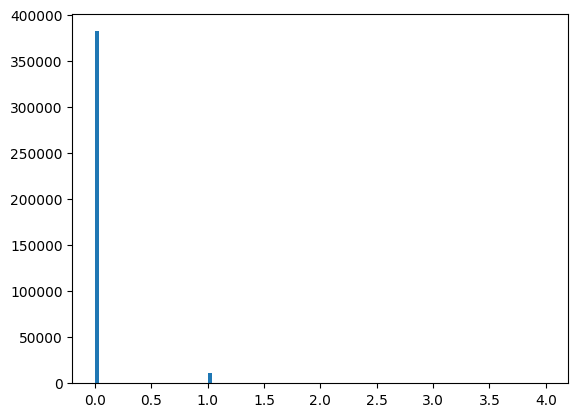

In [86]:
# Get distribution of Hnrnpa1 expression in adata
gene = adata.X[:, adata.var_names == 'Hnrnpa1']

# Convert to vector
gene = gene.toarray().reshape(-1)

# plot histogram
import matplotlib.pyplot as plt
plt.hist(gene, bins=100)
plt.show()


In [82]:
# Count number of cells with Hnrnpa1 expression > 0
num_cells = sum(gene > 0)

1


In [87]:
# Create dataframe from the vector
import pandas as pd
df = pd.DataFrame(gene, columns=['Hnrnpa1'])

In [88]:
df['Hnrnpa1'].describe()

count    393543.000000
mean          0.030004
std           0.177691
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: Hnrnpa1, dtype: float64

In [89]:
df['Hnrnpa1'].value_counts()

Hnrnpa1
0.0    382205
1.0     10883
2.0       441
3.0        13
4.0         1
Name: count, dtype: int64

In [6]:
# let's make the var names unique; this improves performance in accessing the tabular data and is necessary to be able to plot the data
for table in sdata.tables.values():
    table.var_names_make_unique()

INFO     Using 'datashader' as plotting backend.                                                                   


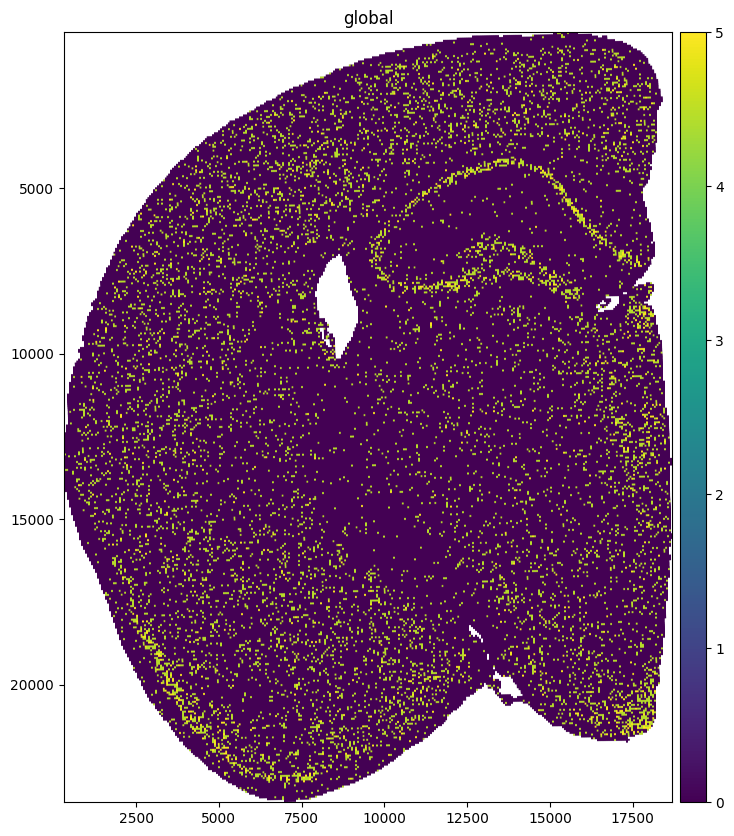

In [9]:
# Plot Hnrnpa1 expression on the spatial data
plt.figure(figsize=(10, 10))
ax = plt.gca()

gene_name = "Hnrnpa1"
sdata.pl.render_shapes("Visium_HD_Mouse_Brain_square_016um", color=gene_name, method="datashader").pl.show(
    coordinate_systems="global", ax=ax
)


In [7]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[1200, 1400], max_coordinate=[2000, 2200], axes=("x", "y"), target_coordinate_system="downscaled_hires"
)


INFO     Using 'datashader' as plotting backend.                                                                   


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/geopandas/geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


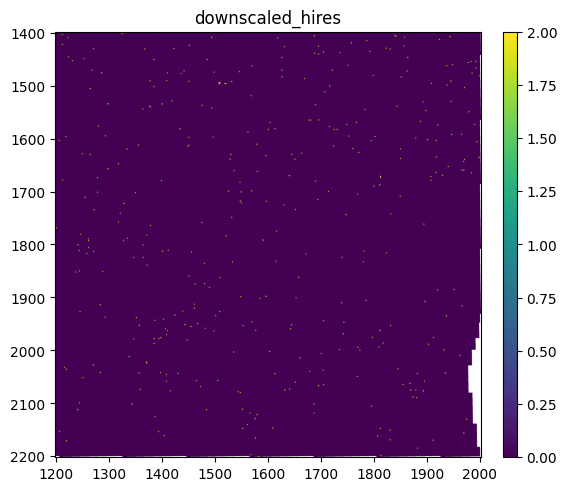

In [8]:
gene_name = "Hnrnpa1"
sdata_small.pl.render_shapes("Visium_HD_Mouse_Brain_square_002um", color=gene_name, method="datashader").pl.show(
    coordinate_systems="downscaled_hires"
)

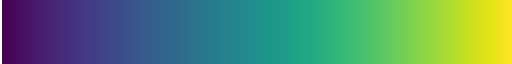

In [67]:
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent

# let's display the areas where no expression is detected as transparent
new_cmap = set_zero_in_cmap_to_transparent(cmap="viridis")
new_cmap

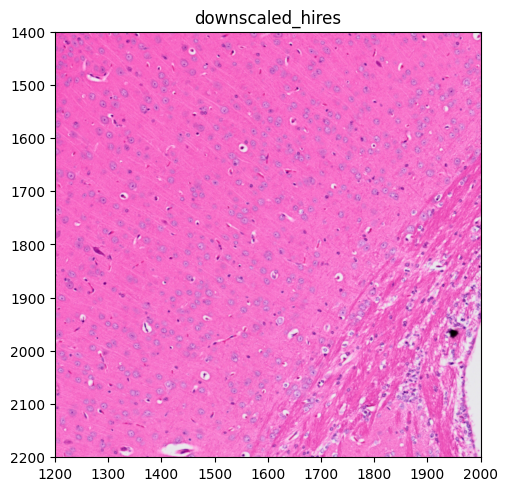

In [68]:
sdata_small.pl.render_images("Visium_HD_Mouse_Brain_hires_image").pl.show(coordinate_systems="downscaled_hires")

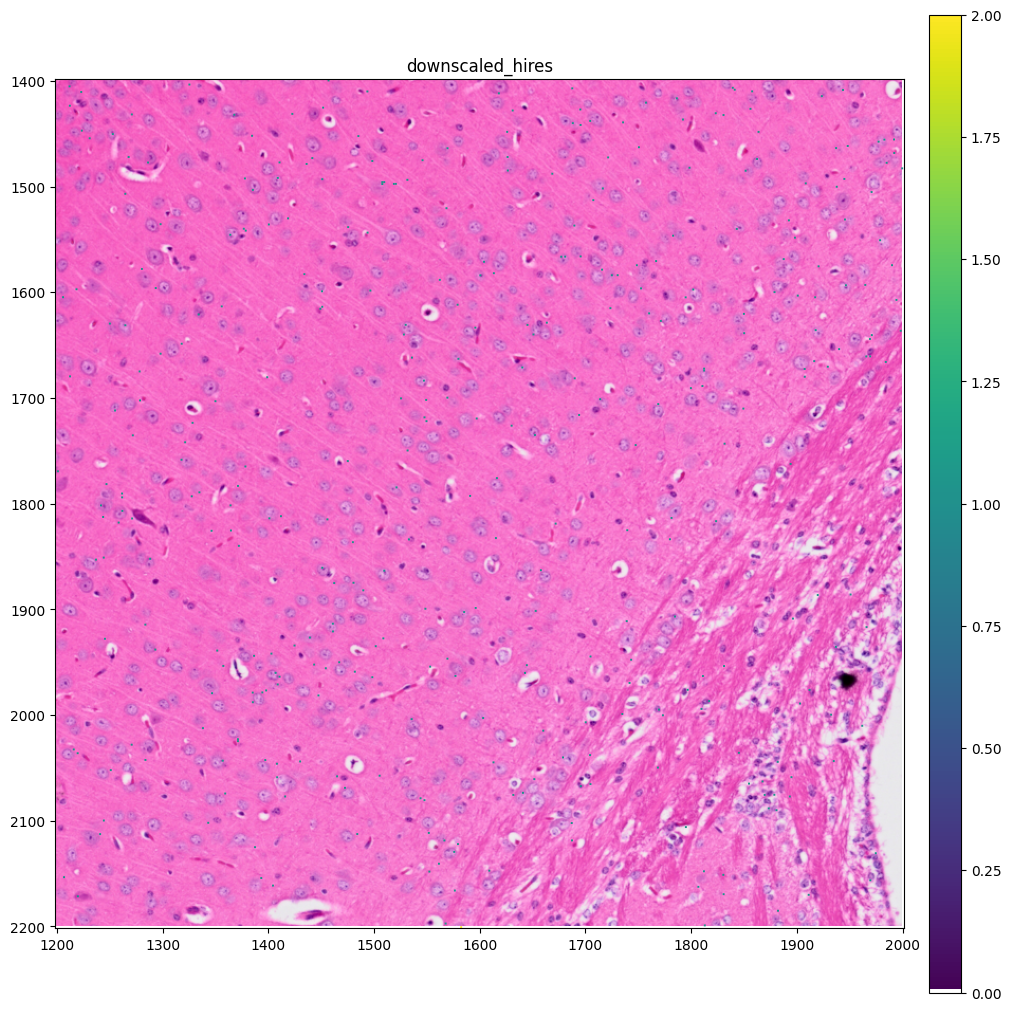

In [71]:
gene_name = "Hnrnpa1"

sdata_small.pl.render_images("Visium_HD_Mouse_Brain_hires_image").pl.render_shapes("Visium_HD_Mouse_Brain_square_002um", color=gene_name, cmap=new_cmap, method='matplotlib').pl.show(coordinate_systems="downscaled_hires", figsize=(10, 10))